# Implementasi Algoritma LightGBM untuk Klasifikasi dan Prediksi Kualitas Udara Berbasis Rekomendasi Kesehatan dan Visualisasi Interaktif Menggunakan Web pada Wilayah DKI Jakarta

# Import Library

In [2]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import mean_absolute_error
from imblearn.over_sampling import SMOTE

In [3]:
import subprocess
subprocess.run(['pip', 'install', 'holidays', 'xgboost'], capture_output=True)

CompletedProcess(args=['pip', 'install', 'holidays', 'xgboost'], returncode=0, stdout=b'Requirement already satisfied: holidays in c:\\Users\\wldn\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages (0.99)\r\nRequirement already satisfied: xgboost in c:\\Users\\wldn\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages (2.0.3)\r\nRequirement already satisfied: python-dateutil<3,>=2.9.0.post0 in c:\\Users\\wldn\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages (from holidays) (2.9.0.post0)\r\nRequirement already satisfied: six>=1.5 in c:\\Users\\wldn\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages (from python-dateutil<3,>=2.9.0.post0->holidays) (1.17.0)\r\nRequirement already satisfied: numpy in c:\\Users\\wldn\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages (from xgboost) (2.3.5)\r\nRequirement already satisfied: scipy in c:\\Users\\wldn\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages (from xgboo

# 1. Gabung Dataset tahun 2019-2025 dan Load dataset

In [4]:
# buat folder untuk output
os.makedirs('model', exist_ok=True)
os.makedirs('output', exist_ok=True)

## 1.1 Standarisasi Dataset dan Konstanta

In [5]:
# Konstanta
polutan = ['pm10', 'pm25', 'so2', 'co', 'o3', 'no2']
target_col = 'kategori'
stasiun_col = 'lokasi_spku'
urutan_kelas = ['BAIK', 'SEDANG', 'TIDAK SEHAT', 'SANGAT TIDAK SEHAT', 'BERBAHAYA']
warna_kelas = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#8e44ad']

# batas nilai ISPU (standar KLHK)
batas_atas = {'pm10':600, 'pm25':600, 'so2':2620,
                  'co':57500, 'o3':800,  'no2':3000}

# standarisasi nama stasiun
map_stasiun = {
    # DKI1
    'DKI1 BUNDERAN HI'                        : 'DKI1 (Bunderan HI)',
    'DKI1 BUNDERAN HI JAKARTA PUSAT'          : 'DKI1 (Bunderan HI)',
    'DKI1 (BUNDERAN HI)'                      : 'DKI1 (Bunderan HI)',
    'DKI1 BUNDARAN HOTEL INDONESIA (HI)'      : 'DKI1 (Bunderan HI)',
    'DKI1 BUNDARAN HOTEL INDONESIA HI'        : 'DKI1 (Bunderan HI)',
    'DKI1'                                    : 'DKI1 (Bunderan HI)',
    # DKI2
    'DKI2 KELAPA GADING'                      : 'DKI2 (Kelapa Gading)',
    'DKI2 KELAPA GADING JAKARTA UTARA'        : 'DKI2 (Kelapa Gading)',
    'DKI2 (KELAPA GADING)'                    : 'DKI2 (Kelapa Gading)',
    'DKI2'                                    : 'DKI2 (Kelapa Gading)',
    # DKI3
    'DKI3 JAGAKARSA'                          : 'DKI3 (Jagakarsa)',
    'DKI3 JAGAKARSA JAKARTA SELATAN'          : 'DKI3 (Jagakarsa)',
    'DKI3 (JAGAKARSA)'                        : 'DKI3 (Jagakarsa)',
    'DKI3'                                    : 'DKI3 (Jagakarsa)',
    # DKI4
    'DKI4 LUBANG BUAYA'                       : 'DKI4 (Lubang Buaya)',
    'DKI4 LUBANG BUAYA JAKARTA TIMUR'         : 'DKI4 (Lubang Buaya)',
    'DKI4 (LUBANG BUAYA)'                     : 'DKI4 (Lubang Buaya)',
    'DKI4'                                    : 'DKI4 (Lubang Buaya)',
    # DKI5
    'DKI5 KEBON JERUK'                        : 'DKI5 (Kebon Jeruk)',
    'DKI5 KEBON JERUK JAKARTA BARAT'          : 'DKI5 (Kebon Jeruk)',
    'DKI5 (KEBON JERUK)'                      : 'DKI5 (Kebon Jeruk)',
    'DKI5 (KEBON JERUK) JAKARTA BARAT'        : 'DKI5 (Kebon Jeruk)',
    'DKI5'                                    : 'DKI5 (Kebon Jeruk)',
}

print (f' Polutan :  {polutan}')
print (f' Kategori : {urutan_kelas}')

 Polutan :  ['pm10', 'pm25', 'so2', 'co', 'o3', 'no2']
 Kategori : ['BAIK', 'SEDANG', 'TIDAK SEHAT', 'SANGAT TIDAK SEHAT', 'BERBAHAYA']


## 1.2 Baca semua Dataset

In [6]:
df = pd.read_csv(r"C:\Penulisan Ilmiah\backend\data\mentah\ispu_gabungan_2019_2025.csv")

print(f'Baris dan Kolom : {df.shape[0]:,} baris x {df.shape[1]} kolom')
print(f'Nama kolom : {list(df.columns)}')
df.head(10)

Baris dan Kolom : 8,227 baris x 12 kolom
Nama kolom : ['periode_data', 'tanggal', 'lokasi_spku', 'pm10', 'pm25', 'so2', 'co', 'o3', 'no2', 'max', 'critical', 'kategori']


,periode_data,tanggal,lokasi_spku,pm10,pm25,so2,co,o3,no2,max,critical,kategori
0,202302,2023-02-25,DKI5 KEBON JERUK JAKARTA BARAT,35,-,13,12,31,18,35,PM10,BAIK
1,202302,2023-02-26,DKI5 KEBON JERUK JAKARTA BARAT,23,-,14,9,32,11,32,O3,BAIK
2,202302,2023-02-27,DKI5 KEBON JERUK JAKARTA BARAT,20,-,13,8,33,13,33,O3,BAIK
3,202302,2023-02-28,DKI5 KEBON JERUK JAKARTA BARAT,30,-,21,11,28,18,30,PM10,BAIK
4,202303,2023-03-01,DKI1 BUNDERAN HI,38,44,50,8,19,27,50,3,BAIK
5,202303,2023-03-02,DKI1 BUNDERAN HI,29,33,47,11,21,27,47,3,BAIK
6,202303,2023-03-03,DKI1 BUNDERAN HI,38,46,49,9,16,25,49,3,BAIK
7,202303,2023-03-04,DKI1 BUNDERAN HI,31,40,50,---,18,21,50,3,BAIK
8,202303,2023-03-05,DKI1 BUNDERAN HI,33,41,47,11,21,22,47,3,BAIK
9,202303,2023-03-06,DKI1 BUNDERAN HI,31,44,46,9,20,19,46,3,BAIK


# 2. Eksplorasi Data Awal (EDA)

In [7]:
print('Tipe Data')
print(df.dtypes)

print('\n Missing Value')
mv     = df.isnull().sum()
mv_pct = (mv / len(df) * 100).round(2)
mv_df  = pd.DataFrame({'Jumlah': mv, 'Persen (%)': mv_pct})
print(mv_df[mv_df['Jumlah'] > 0])


print('Distribusi Kategori')
if target_col in df.columns:
    print(df[target_col].value_counts(dropna=False))

print('\n Stastistik Deskriptif')
df.describe()

Tipe Data
periode_data    int64
tanggal           str
lokasi_spku       str
pm10              str
pm25              str
so2               str
co                str
o3                str
no2               str
max               str
critical          str
kategori          str
dtype: object

 Missing Value
          Jumlah  Persen (%)
pm10         264        3.21
pm25         834       10.14
so2           56        0.68
co            50        0.61
o3            46        0.56
no2           69        0.84
max            8        0.10
critical      96        1.17
kategori       2        0.02
Distribusi Kategori
kategori
SEDANG                6038
TIDAK SEHAT           1208
BAIK                   879
TIDAK ADA DATA          57
O3                      31
SANGAT TIDAK SEHAT      12
NaN                      2
Name: count, dtype: int64

 Stastistik Deskriptif


,periode_data
count,8227.000000
mean,202288.482436
std,173.760081
min,201901.000000
25%,202109.000000
50%,202307.000000
75%,202410.000000
max,202511.000000


# 3. Cleaning data

## 3.1 Hapus kolom Duplikat

In [8]:
kolom_dup = [c for c in df.columns
             if '.' in str(c) and c.split('.')[-1].isdigit()]

if kolom_dup:
    df.drop(columns = kolom_dup, inplace=True)
    print(f'Kolom duplikat telah dihapus : {kolom_dup}')
else:
    print('Tidak ada kolom yang duplikat')


Tidak ada kolom yang duplikat


## 3.2 Standarisasi nama kolom 

In [9]:
df.columns = df.columns.str.strip().str.lower()
df.rename(columns = {
    'pm_sepuluh'              : 'pm10',
    'pm_duakomalima'          : 'pm25',
    'sulfur_dioksida'         : 'so2',
    'karbon_monoksida'        : 'co',
    'ozon'                    : 'o3',
    'nitrogen_dioksida'       : 'no2',
    'parameter_pencemar_kritis': 'critical',
    'stasiun'                 : 'lokasi_spku',
    'categori'                : 'kategori',
}, inplace=True)

print(f'Nama kolom distandardisasi')

Nama kolom distandardisasi


## 3.3 Konversi tanggal pada dataset

In [10]:
def rekonstruksi_tanggal(row):
 
    tgl_raw    = str(row['tanggal']).strip()
    periode    = str(int(row['periode_data'])) if pd.notna(row['periode_data']) else ''

    # parse langsung tanggal 
    try:
        hasil = pd.to_datetime(tgl_raw, dayfirst=True)
        if hasil.year > 2000:   # pastikan bukan salah parse
            return hasil
    except:
        pass

    # Menggunakan format hari saja pada dataset
    try:
        if tgl_raw.isdigit() and len(periode) >= 6:
            tahun = int(periode[:4])
            bulan = int(periode[4:6])
            hari  = int(tgl_raw)

            # Validasi hari (1-31)
            if 1 <= hari <= 31:
                return pd.Timestamp(year=tahun, month=bulan, day=hari)
    except:
        pass

    # ── Fallback: ambil dari periode_data saja (hari=1) ───────
    try:
        if len(periode) >= 6:
            tahun = int(periode[:4])
            bulan = int(periode[4:6])
            return pd.Timestamp(year=tahun, month=bulan, day=1)
    except:
        pass

    return pd.NaT

# Terapkan fungsi ke seluruh dataframe
print('Merekonstruksi kolom tanggal...')
df['tanggal'] = df.apply(rekonstruksi_tanggal, axis=1)

# Cek hasilnya
n_gagal = df['tanggal'].isna().sum()
print(f'Berhasil   : {df["tanggal"].notna().sum():,} baris')
print(f'Gagal (NaT): {n_gagal:,} baris')

print(f'\nDistribusi tahun setelah rekonstruksi:')
print(df['tanggal'].dt.year.value_counts().sort_index())

# Hapus hanya yang benar-benar tidak bisa diselamatkan
df.dropna(subset=['tanggal'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'\nTotal data tersisa: {len(df):,} baris')

Merekonstruksi kolom tanggal...
Berhasil   : 8,227 baris
Gagal (NaT): 0 baris

Distribusi tahun setelah rekonstruksi:
tanggal
2019     345
2020     394
2021    1825
2022     492
2023    1670
2024    1830
2025    1671
Name: count, dtype: int64

Total data tersisa: 8,227 baris


## 3.4 Konversi Polutan ke numerik

In [11]:
nilai_invalid = ['-', '---', 'TIDAK ADA DATA', 'None', 'none', '', ' ']
for col in polutan:
    if col in df.columns:
        df[col] = df[col].replace(nilai_invalid, np.nan)
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f' Konversi polutan ke Numerik ')

 Konversi polutan ke Numerik 


## 3.5 Standarisasi Kategori target

In [12]:
df[target_col] = df[target_col].astype(str).str.strip().str.upper()
df[target_col].replace({
    'GOOD'          : 'BAIK',
    'MODERATE'      : 'SEDANG',
    'UNHEALTHY'     : 'TIDAK SEHAT',
    'VERY UNHEALTHY': 'SANGAT TIDAK SEHAT',
    'HAZARDOUS'     : 'BERBAHAYA',
    'NAN'           : np.nan,
    'NONE'          : np.nan,
    '-'             : np.nan,
    'TIDAK ADA DATA': np.nan,
    'O3'            : np.nan,  # kategori tidak valid
}, inplace=True)
print(f'Kategori target distandardisasi ')

Kategori target distandardisasi 


## 3.6 Standarisasi nama stasiun

In [13]:
df[stasiun_col] = (
    df[stasiun_col].astype(str).str.strip().str.upper()
    .map(lambda x: map_stasiun.get(x, x))
)
print(f'Nama stasiun distandardisasi ')
print(f'Stasiun unik: {df[stasiun_col].unique()}')

Nama stasiun distandardisasi 
Stasiun unik: <ArrowStringArray>
[  'DKI5 (Kebon Jeruk)',   'DKI1 (Bunderan HI)', 'DKI2 (Kelapa Gading)',
     'DKI3 (Jagakarsa)',  'DKI4 (Lubang Buaya)',   'SANGAT TIDAK SEHAT',
          'TIDAK SEHAT',               'SEDANG',                 'BAIK',
                    '0']
Length: 10, dtype: str


## 3.7 Menghapus Duplikat

In [14]:
nilai_sebelum = len(df)
df.drop_duplicates(subset=['tanggal', stasiun_col], keep='first', inplace= True)
print(f'Duplikat pada dataset telah dihapus: {nilai_sebelum - len(df):,}baris')

Duplikat pada dataset telah dihapus: 42baris


## 3.8 Hapus Kategori yang tidak penting

In [15]:
stasiun_valid = list(set(map_stasiun.values()))

nilai_sebelum = len(df)
df.dropna(subset=[target_col], inplace=True)
df = df[df[target_col].isin(urutan_kelas)].copy()
df = df[df[stasiun_col].isin(stasiun_valid)].copy()

df.reset_index(drop=True, inplace=True)
print(f'Baris tidak valid dihapus: {nilai_sebelum - len(df):,} baris')
print('─' * 50)
print(f'Data setelah pembersihan: {len(df):,} baris')
print(f'Stasiun unik: {sorted(df[stasiun_col].unique().tolist())}')
print(f'\nDistribusi kategori:')
print(df[target_col].value_counts())

Baris tidak valid dihapus: 90 baris
──────────────────────────────────────────────────
Data setelah pembersihan: 8,095 baris
Stasiun unik: ['DKI1 (Bunderan HI)', 'DKI2 (Kelapa Gading)', 'DKI3 (Jagakarsa)', 'DKI4 (Lubang Buaya)', 'DKI5 (Kebon Jeruk)']

Distribusi kategori:
kategori
SEDANG                6003
TIDAK SEHAT           1203
BAIK                   877
SANGAT TIDAK SEHAT      12
Name: count, dtype: int64


## 3.9 Visualisasi Distribusi Kategori ISPU

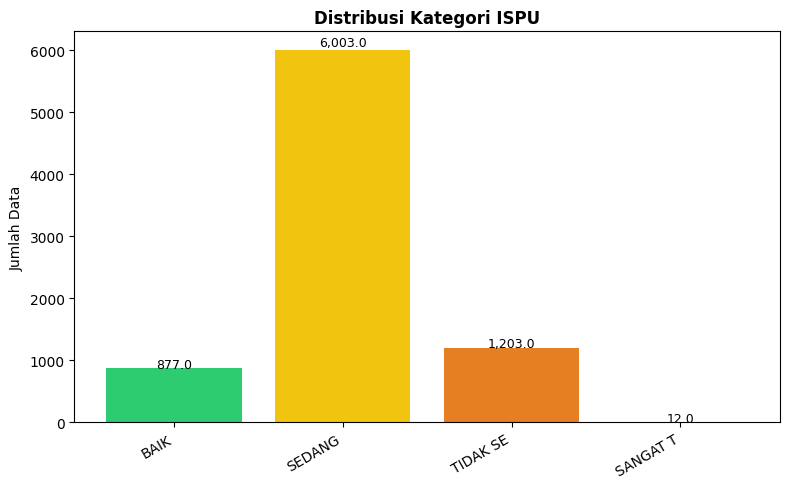

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
counts = df[target_col].value_counts().reindex(urutan_kelas).dropna()
bars = ax.bar(range(len(counts)), counts.values, color=warna_kelas[:len(counts)])
ax.set_xticks(range(len(counts)))
ax.set_xticklabels([k[:8] for k in counts.index], rotation=30, ha='right')
ax.set_title('Distribusi Kategori ISPU', fontweight='bold')
ax.set_ylabel('Jumlah Data')
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, v + (v * 0.01), f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# 4. Penanganan Missing Value

## 4.1 Lihat Missing Value sebelum di imputasi

In [17]:
print('Missing Value per polutan (Sebelum di Imputasi)')
for col in polutan:
    if col in df.columns:
        n = df[col].isna().sum()
        pct = n / len(df) * 100
        print(f'  {col:6s}: {n:5,} ({pct:.1f}%)')
df_sebelum_imputasi = df.copy()


Missing Value per polutan (Sebelum di Imputasi)
  pm10  :   496 (6.1%)
  pm25  : 1,077 (13.3%)
  so2   :   151 (1.9%)
  co    :    72 (0.9%)
  o3    :    85 (1.1%)
  no2   :   112 (1.4%)


## 4.2 Penanganan Missing value dengan median per stasiun per bulan

In [18]:
df['bulan_tmp'] = pd.to_datetime(df['tanggal']).dt.month

for col in polutan:
    if col in df.columns:
        # Median per stasiun per bulan
        med_grp = df.groupby([stasiun_col, 'bulan_tmp'])[col].transform('median')
        # Fallback median per stasiun
        med_st = df.groupby(stasiun_col)[col].transform('median')
        # fallback median keseluruhan
        med_keseluruhan = df[col].median()
        df[col] = df[col].fillna(med_grp).fillna(med_st).fillna(med_keseluruhan)

df.drop(columns = ['bulan_tmp'], inplace=True)

mv = df[polutan].isna().sum().sum()
print(f'\nMissing values setelah imputasi: {mv}')


Missing values setelah imputasi: 0


## 4.3 Visualisasi Sebelum VS Setelah Imputasi

In [19]:
# Hitung missing value SEBELUM imputasi (dari df asli)
missing_sebelum = df_sebelum_imputasi[polutan].isna().sum()

# Hitung missing value SESUDAH imputasi
missing_sesudah = df[polutan].isna().sum()

# Tampilkan untuk verifikasi
print("Missing Value Sebelum Imputasi:")
print(missing_sebelum)
print("\nMissing Value Sesudah Imputasi:")
print(missing_sesudah)

Missing Value Sebelum Imputasi:
pm10     496
pm25    1077
so2      151
co        72
o3        85
no2      112
dtype: int64

Missing Value Sesudah Imputasi:
pm10    0
pm25    0
so2     0
co      0
o3      0
no2     0
dtype: int64


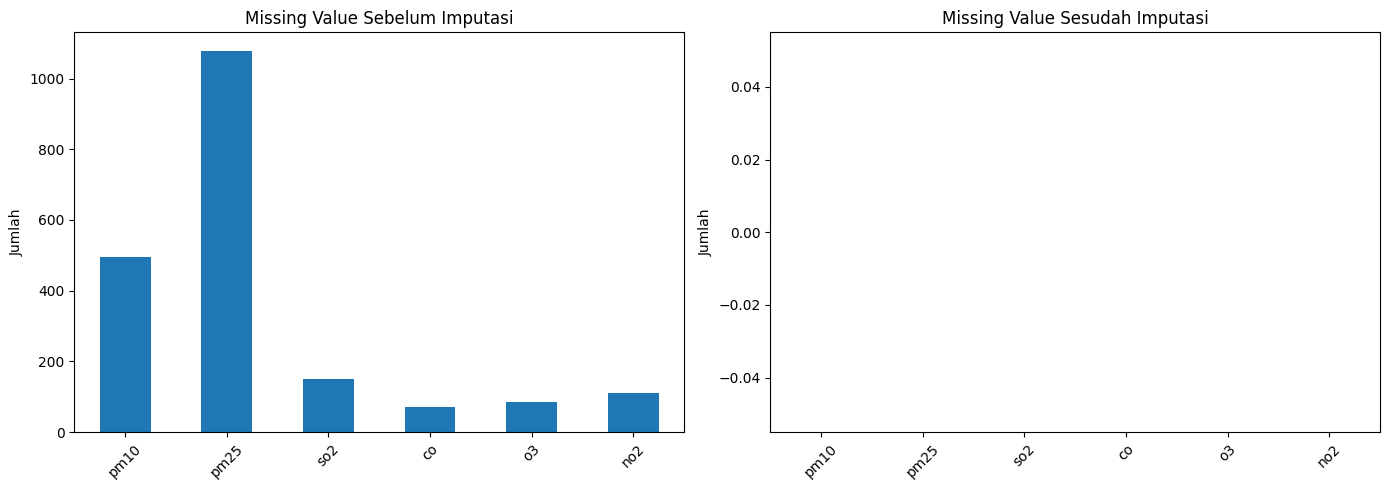

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sebelum imputasi
missing_sebelum.plot(kind='bar', ax=axes[0])
axes[0].set_title('Missing Value Sebelum Imputasi')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=45)

# Sesudah imputasi
missing_sesudah.plot(kind='bar', ax=axes[1])
axes[1].set_title('Missing Value Sesudah Imputasi')
axes[1].set_ylabel('Jumlah')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 5. Penanganan Outlier

In [21]:
for col in polutan:
    if col in df.columns:
        n_neg = (df[col] < 0).sum()
        n_over = (df[col] > batas_atas[col]).sum()
        df[col] = df[col].clip(lower=0, upper = batas_atas[col])
        df_sebelum_outlier = df.copy()

        status = []
        if n_neg > 0: status.append(f'{n_neg} negatif')
        if n_over > 0: status.append(f'{n_neg} melebihi batas')
        info = ','.join(status) if status else 'tidak ada outlier'
        print(f' {col:6s} [0- {batas_atas[col]:>6,}]: {info}')
print('\n outlier sudah ditangani')

 pm10   [0-    600]: tidak ada outlier
 pm25   [0-    600]: tidak ada outlier
 so2    [0-  2,620]: tidak ada outlier
 co     [0- 57,500]: tidak ada outlier
 o3     [0-    800]: tidak ada outlier
 no2    [0-  3,000]: tidak ada outlier

 outlier sudah ditangani


## 5.1 Visualisasi Boxplot untuk penanganan Outlier

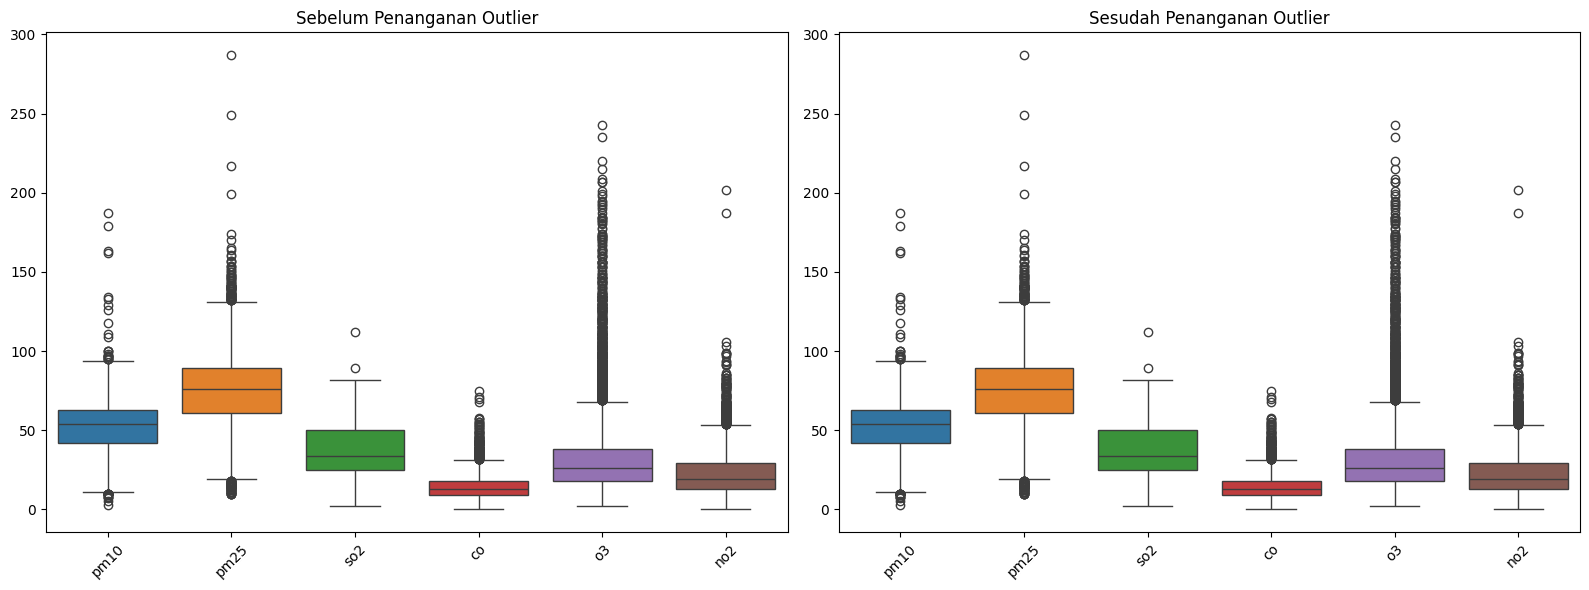

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sebelum
sns.boxplot(data=df_sebelum_outlier[polutan], ax=axes[0])
axes[0].set_title('Sebelum Penanganan Outlier')
axes[0].tick_params(axis='x', rotation=45)

# Sesudah
sns.boxplot(data=df[polutan], ax=axes[1])
axes[1].set_title('Sesudah Penanganan Outlier')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 6. Feature Engineering (untuk fitur interaksi polutan)

## 6.1 Fitur untuk interaksi polutan

In [23]:
df['pm_total'] = (df['pm10'] + df['pm25']).round(2)
df['pm_ratio'] = (df['pm25'] / (df['pm10'] + 1e-6)).round(2)
df['nox'] = (df['no2'] + df['o3']).round(2)

print('Fitur interaksi: pm_total, pm_ratio, nox')

Fitur interaksi: pm_total, pm_ratio, nox


### 6.1.1 Visualisasi Fitur interaksi polutan

<Figure size 1000x500 with 0 Axes>

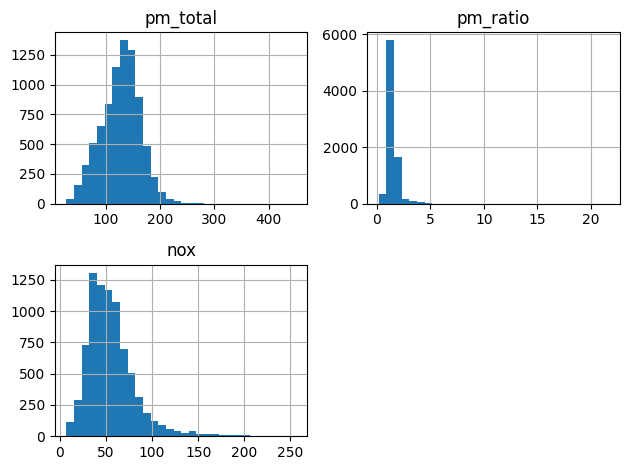

In [24]:
fitur_baru = ['pm_total', 'pm_ratio', 'nox']

plt.figure(figsize=(10,5))
df[fitur_baru].hist(bins=30)
plt.tight_layout()
plt.show()

## 6.2 Rolling Average 3 hari per stasiun

In [25]:
df = df.sort_values([stasiun_col, 'tanggal'])
for col in ['pm10', 'pm25']:
    df[f'{col}_avg3'] = (
        df.groupby(stasiun_col)[col]
        .transform(lambda x: x.rolling(3, min_periods=1).mean())
        .round(2)
    )
df.reset_index(drop=True, inplace=True)
print('Rolling average 3 hari: pm10_avg3, pm25_avg3 ')
print(f'\nTotal fitur polutan: {["pm_total","pm_ratio","nox","pm10_avg3","pm25_avg3"]}')

Rolling average 3 hari: pm10_avg3, pm25_avg3 

Total fitur polutan: ['pm_total', 'pm_ratio', 'nox', 'pm10_avg3', 'pm25_avg3']


# 7. Fitur Temporal

In [26]:
import holidays

id_holidays = holidays.Indonesia(years=range(2019, 2026))

df['is_weekend'] = pd.to_datetime(df['tanggal']).dt.dayofweek >= 5
df['is_holiday'] = pd.to_datetime(df['tanggal']).apply(
    lambda x: x.date() in id_holidays
)
df['is_libur'] = (df['is_weekend'] | df['is_holiday']).astype(int)

print(f"Hari libur/weekend: {df['is_libur'].sum():,} hari ({df['is_libur'].mean()*100:.1f}%)")
print(f"Hari kerja        : {(df['is_libur']==0).sum():,} hari")

Hari libur/weekend: 2,569 hari (31.7%)
Hari kerja        : 5,526 hari


In [27]:
# Ekstrak komponen waktu 
df['tahun'] = df['tanggal'].dt.year
df['bulan'] = df['tanggal'].dt.month
df['hari']  = df['tanggal'].dt.day_of_week  # 0=Senin, 6=Minggu

# Kode musim Indonesia
df['musim'] = df['bulan'].map({
    12:0, 1:0,  2:0,
     3:1, 4:1,  5:1,
     6:2, 7:2,  8:2,
     9:3,10:3, 11:3
})

# Label musim (untuk visualisasi)
df['musim_label'] = df['musim'].map({
    0:'Hujan', 1:'Pancaroba I',
    2:'Kemarau', 3:'Pancaroba II'
})

# Periode pandemi
df['periode_pandemi'] = pd.cut(
    df['tahun'],
    bins   = [2018, 2019, 2021, 2026],
    labels = ['Sebelum Pandemi', 'Saat Pandemi', 'Pasca Pandemi']
)
import holidays

# is_pandemi (numerik untuk model)
df['is_pandemi'] = pd.to_datetime(df['tanggal']).apply(
    lambda x: 1 if pd.Timestamp('2020-03-01') <= x <= pd.Timestamp('2022-06-30') else 0
)

# Hari libur & weekend
id_holidays      = holidays.Indonesia(years=range(2019, 2026))
df['is_weekend'] = pd.to_datetime(df['tanggal']).dt.dayofweek >= 5
df['is_holiday'] = pd.to_datetime(df['tanggal']).apply(
    lambda x: x.date() in id_holidays
)
df['is_libur']   = (df['is_weekend'] | df['is_holiday']).astype(int)
# ─────────────────────────────────────────────────────────────────

print('Fitur temporal berhasil dibuat:')
print(f'  tahun, bulan, hari, musim, musim_label, periode_pandemi')
print(f'  is_pandemi, is_libur, is_weekend, is_holiday')
print(f'\nRentang data: {df["tanggal"].min().date()} s/d {df["tanggal"].max().date()}')
print(f'\nDistribusi tahun:')
print(df['tahun'].value_counts().sort_index())
print(f'\nis_pandemi : {df["is_pandemi"].sum():,} hari')
print(f'is_libur   : {df["is_libur"].sum():,} hari libur/weekend')

Fitur temporal berhasil dibuat:
  tahun, bulan, hari, musim, musim_label, periode_pandemi
  is_pandemi, is_libur, is_weekend, is_holiday

Rentang data: 2019-01-01 s/d 2025-11-30

Distribusi tahun:
tahun
2019     345
2020     353
2021    1808
2022     460
2023    1649
2024    1824
2025    1656
Name: count, dtype: int64

is_pandemi : 2,272 hari
is_libur   : 2,569 hari libur/weekend


# 7.1 Import fitur holiday untuk fitur temporal

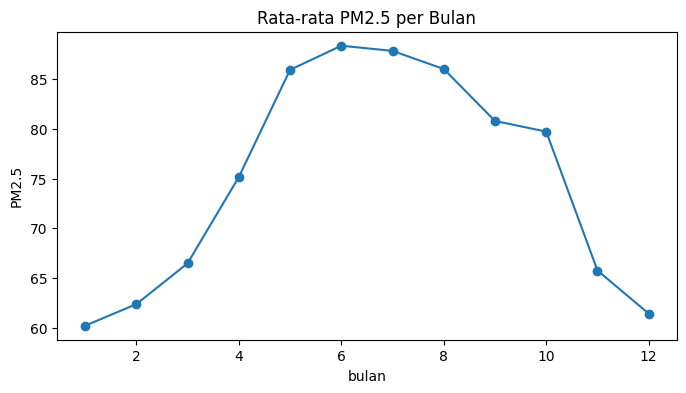

In [28]:
bulanan = df.groupby('bulan')['pm25'].mean()

plt.figure(figsize=(8,4))
bulanan.plot(marker='o')
plt.title('Rata-rata PM2.5 per Bulan')
plt.ylabel('PM2.5')
plt.show()

# 8. Fitur Lag (Time-Series)

In [29]:
# 8. Fitur Lag & Rolling Window (Time-Series)
df = df.sort_values([stasiun_col, 'tanggal'])
nilai_sebelum = len(df)

# Lag 1, 2, 3, 7, 14 hari per stasiun
for p in polutan:
    for lag in [1, 2, 3, 7, 14]:
        df[f'{p}_lag{lag}'] = df.groupby(stasiun_col)[p].shift(lag)

# Rolling average per stasiun
for p in ['pm10', 'pm25', 'o3', 'no2']:
    for window in [3, 7, 14]:
        df[f'{p}_avg{window}'] = df.groupby(stasiun_col)[p].transform(
            lambda x: x.shift(1).rolling(window, min_periods=1).mean()
        )

# Standar deviasi rolling PM2.5 (volatilitas)
df['pm25_std7'] = df.groupby(stasiun_col)['pm25'].transform(
    lambda x: x.shift(1).rolling(7, min_periods=1).std()
).fillna(0)

df.reset_index(drop=True, inplace=True)

# Hapus baris dengan lag NaN (lag 14 butuh minimal 14 hari)
df.dropna(subset=[f'{col}_lag14' for col in polutan], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Fitur lag & rolling selesai dibuat:')
print(f'  Lag    : {[f"{p}_lag{l}" for p in polutan for l in [1,2,3,7,14]][:6]} ...')
print(f'  Rolling: {[f"{p}_avg{w}" for p in ["pm10","pm25"] for w in [3,7,14]]}')
print(f'  Std    : pm25_std7')
print(f'\nBaris sebelum : {nilai_sebelum:,}')
print(f'Baris sesudah : {len(df):,} (berkurang karena lag NaN dihapus)')

Fitur lag & rolling selesai dibuat:
  Lag    : ['pm10_lag1', 'pm10_lag2', 'pm10_lag3', 'pm10_lag7', 'pm10_lag14', 'pm25_lag1'] ...
  Rolling: ['pm10_avg3', 'pm10_avg7', 'pm10_avg14', 'pm25_avg3', 'pm25_avg7', 'pm25_avg14']
  Std    : pm25_std7

Baris sebelum : 8,095
Baris sesudah : 8,025 (berkurang karena lag NaN dihapus)


In [30]:
# Rata-rata polutan seluruh Jakarta per hari (konteks kota)
for p in ['pm10', 'pm25', 'o3', 'no2']:
    kota_avg = df.groupby('tanggal')[p].mean().rename(f'{p}_kota_avg')
    df = df.merge(kota_avg, on='tanggal', how='left')

print("Fitur rata-rata kota ditambahkan:")
print([c for c in df.columns if 'kota' in c])
print(f"\nShape df: {df.shape}")

Fitur rata-rata kota ditambahkan:
['pm10_kota_avg', 'pm25_kota_avg', 'o3_kota_avg', 'no2_kota_avg']

Shape df: (8025, 72)


# 9. Fitur Cuaca

In [31]:
import openmeteo_requests
import requests_cache
from retry_requests import retry

# ── 1. Download data cuaca historis ──────────────────────────────
cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

params = {
    "latitude": -6.2088,
    "longitude": 106.8456,
    "start_date": "2019-01-01",
    "end_date": "2025-11-30",
    "daily": [
        "temperature_2m_mean",
        "relative_humidity_2m_mean",
        "wind_speed_10m_max",
        "precipitation_sum",
        "shortwave_radiation_sum"
    ],
    "timezone": "Asia/Jakarta"
}

responses = openmeteo.weather_api(
    "https://archive-api.open-meteo.com/v1/archive", params=params
)

response = responses[0]
daily = response.Daily()

df_cuaca = pd.DataFrame({
    "tanggal_cuaca"   : pd.date_range(
        start=pd.Timestamp(daily.Time(), unit="s"),
        end=pd.Timestamp(daily.TimeEnd(), unit="s"),
        freq=pd.Timedelta(seconds=daily.Interval()),
        inclusive="left"
    ).strftime("%Y-%m-%d"),
    "suhu"            : daily.Variables(0).ValuesAsNumpy(),
    "kelembaban"      : daily.Variables(1).ValuesAsNumpy(),
    "kecepatan_angin" : daily.Variables(2).ValuesAsNumpy(),
    "curah_hujan"     : daily.Variables(3).ValuesAsNumpy(),
    "radiasi_matahari": daily.Variables(4).ValuesAsNumpy(),
})

df_cuaca.to_csv("data/cuaca_jakarta_2019_2025.csv", index=False)
print(f"Data cuaca diunduh: {df_cuaca.shape[0]} baris")
print(df_cuaca.head(3))

# ── 2. Merge ke df utama ─────────────────────────────────────────
# Hapus kolom cuaca lama jika sudah ada
kolom_cuaca = ['suhu', 'kelembaban', 'kecepatan_angin', 'curah_hujan', 'radiasi_matahari']
df.drop(columns=[c for c in kolom_cuaca if c in df.columns], inplace=True)

# Samakan format tanggal
df['tanggal_str'] = pd.to_datetime(df['tanggal']).dt.strftime('%Y-%m-%d')

df = df.merge(
    df_cuaca,
    left_on='tanggal_str',
    right_on='tanggal_cuaca',
    how='left'
)
df.drop(columns=['tanggal_cuaca', 'tanggal_str'], inplace=True)

print(f"\nShape df setelah merge: {df.shape}")
print("Missing value kolom cuaca:")
print(df[kolom_cuaca].isna().sum())

Data cuaca diunduh: 2526 baris
  tanggal_cuaca       suhu  kelembaban  kecepatan_angin  curah_hujan  \
0    2018-12-31  25.581251   86.507507        20.037485     5.900000   
1    2019-01-01  26.720833   80.446663        21.129885     2.300000   
2    2019-01-02  26.347914   80.550316        22.253124     9.000001   

   radiasi_matahari  
0          8.050000  
1         17.719999  
2         12.510000  

Shape df setelah merge: (8025, 77)
Missing value kolom cuaca:
suhu                5
kelembaban          5
kecepatan_angin     5
curah_hujan         5
radiasi_matahari    5
dtype: int64


In [32]:
print('Fitur cuaca (data nyata Open-Meteo):')
print(f'  suhu            : {df["suhu"].mean():.1f}°C rata-rata')
print(f'  kelembaban      : {df["kelembaban"].mean():.1f}% rata-rata')
print(f'  kecepatan_angin : {df["kecepatan_angin"].mean():.1f} km/h rata-rata')
print(f'  curah_hujan     : {df["curah_hujan"].mean():.1f} mm/hari rata-rata')
print(f'  radiasi_matahari: {df["radiasi_matahari"].mean():.1f} MJ/m² rata-rata')
print(f'\nCatatan: saat prediksi, data cuaca diambil real-time dari OpenWeatherMap')

Fitur cuaca (data nyata Open-Meteo):
  suhu            : 27.1°C rata-rata
  kelembaban      : 80.7% rata-rata
  kecepatan_angin : 12.4 km/h rata-rata
  curah_hujan     : 6.7 mm/hari rata-rata
  radiasi_matahari: 18.5 MJ/m² rata-rata

Catatan: saat prediksi, data cuaca diambil real-time dari OpenWeatherMap


# 10. Encoding dan Seleksi Fitur

In [33]:
le_stasiun = LabelEncoder()
df['stasiun_enc'] = le_stasiun.fit_transform(df[stasiun_col].astype(str))

print('Mapping stasiun:')
for i, s in enumerate(le_stasiun.classes_):
    print(f'  {i} → {s}')

Mapping stasiun:
  0 → DKI1 (Bunderan HI)
  1 → DKI2 (Kelapa Gading)
  2 → DKI3 (Jagakarsa)
  3 → DKI4 (Lubang Buaya)
  4 → DKI5 (Kebon Jeruk)


## 10.1 Mapping Kategori

In [34]:
label2idx = {k: i for i, k in enumerate(urutan_kelas)}
idx2label = {v: k for k, v in label2idx.items()}
df['label'] = df[target_col].map(label2idx)

print('\nMapping kategori:')
for k, v in label2idx.items():
    print(f'  {v} → {k}')


Mapping kategori:
  0 → BAIK
  1 → SEDANG
  2 → TIDAK SEHAT
  3 → SANGAT TIDAK SEHAT
  4 → BERBAHAYA


## 10.2. Membuat Fitur untuk Regresi dan Klasifikasi

In [35]:
# ── Fitur untuk model REGRESI ─────────────────────────────────────
regresi = [
    # Cuaca
    'suhu', 'kelembaban', 'kecepatan_angin', 'curah_hujan', 'radiasi_matahari',
    # Temporal
    'tahun', 'bulan', 'hari', 'musim', 'is_pandemi', 'is_libur',
    # Lag 1,2,3,7,14 hari
    *[f'{p}_lag{l}' for p in polutan for l in [1,2,3,7,14]],
    # Rolling average
    *[f'{p}_avg{w}' for p in ['pm10','pm25','o3','no2'] for w in [3,7,14]],
    # Volatilitas
    'pm25_std7',
    # Rata-rata kota
    *[f'{p}_kota_avg' for p in ['pm10','pm25','o3','no2']],
    # Stasiun
    'stasiun_enc',
]

# ── Fitur untuk model KLASIFIKASI ────────────────────────────────
klasifikasi = [
    # Nilai polutan (hasil regresi)
    *polutan,
    # Fitur interaksi
    'pm_total', 'pm_ratio', 'nox',
    # Cuaca
    'suhu', 'kelembaban', 'kecepatan_angin', 'curah_hujan', 'radiasi_matahari',
    # Temporal
    'tahun', 'bulan', 'hari', 'musim', 'is_pandemi', 'is_libur',
    # Lag PM2.5 dan PM10
    *[f'{p}_lag{l}' for p in ['pm10','pm25'] for l in [1,2,3,7,14]],
    # Rolling
    *[f'{p}_avg{w}' for p in ['pm10','pm25'] for w in [3,7,14]],
    'pm25_std7',
    # Rata-rata kota
    *[f'{p}_kota_avg' for p in ['pm10','pm25','o3','no2']],
    # Stasiun
    'stasiun_enc',
]

print(f"Fitur regresi   : {len(regresi)}")
print(f"Fitur klasifikasi: {len(klasifikasi)}")

Fitur regresi   : 59
Fitur klasifikasi: 42


In [36]:
print(f'\nFitur Regresi ({len(regresi)})')
print(f'Fitur Klasifikasi ({len(klasifikasi)})')

fitur_tidak_ada = [f for f in regresi + klasifikasi
                   if f not in df.columns]
if fitur_tidak_ada:
    print(f'\nFitur tidak ditemukan: {fitur_tidak_ada}')
else:
    print('\nSemua fitur tersedia di dataframe')


Fitur Regresi (59)
Fitur Klasifikasi (42)

Semua fitur tersedia di dataframe


# 11. Split data latih dan data uji (80% - 20%)

In [37]:
idx_train, idx_test = train_test_split(
    df.index,
    test_size= 0.2,
    random_state= 42,
    stratify= df['label']
)

df_train = df.loc[idx_train].copy().reset_index(drop = True)
df_test = df.loc[idx_test].copy().reset_index(drop = True)

# data model regresi
x_reg_train = df_train[regresi]
x_reg_test =  df_test[regresi]
# target
y_reg_train = {col: df_train[col] for col in polutan}
y_reg_test = {col: df_test[col] for col in polutan}

# data model klasifikasi
x_klf_train = df_train[klasifikasi]
x_klf_test = df_test[klasifikasi]
y_klf_train = df_train['label']
y_klf_test = df_test['label']

print(f'Total data : {len(df):,} baris')
print(f'data latih : {len(df_train):,} baris')
print(f'Total uji : {len(df_test):,} baris')

Total data : 8,025 baris
data latih : 6,420 baris
Total uji : 1,605 baris


# 12. SMOTE untuk imbalance data

In [38]:
# Bersihkan NaN pada fitur klasifikasi sebelum SMOTE
print(f"Missing value sebelum dibersihkan:")
print(x_klf_train[klasifikasi].isna().sum()[x_klf_train[klasifikasi].isna().sum() > 0])

# Imputasi median per kolom
x_klf_train = x_klf_train.copy()
x_klf_test  = x_klf_test.copy()

for col in klasifikasi:
    if x_klf_train[col].isna().any():
        median_val = x_klf_train[col].median()
        x_klf_train[col] = x_klf_train[col].fillna(median_val)
        x_klf_test[col]  = x_klf_test[col].fillna(median_val)

# Lakukan hal sama untuk fitur regresi
for col in regresi:
    if col in x_reg_train.columns and x_reg_train[col].isna().any():
        median_val = x_reg_train[col].median()
        x_reg_train[col] = x_reg_train[col].fillna(median_val)
        x_reg_test[col]  = x_reg_test[col].fillna(median_val)

print(f"\nMissing value setelah dibersihkan: {x_klf_train[klasifikasi].isna().sum().sum()}")

print("\n Kelas imbalance, menerapkan metode SMOTE")

smote = SMOTE(
    random_state=42,
    k_neighbors=5,
    sampling_strategy='not majority'
)

x_klf_train_smote, y_klf_train_smote = smote.fit_resample(
    x_klf_train[klasifikasi], y_klf_train
)

Missing value sebelum dibersihkan:
suhu                4
kelembaban          4
kecepatan_angin     4
curah_hujan         4
radiasi_matahari    4
dtype: int64

Missing value setelah dibersihkan: 0

 Kelas imbalance, menerapkan metode SMOTE


In [39]:
dist = y_klf_train.value_counts()
rasio = dist.min() / dist.max()

if rasio < 0.3:
    print("\n Kelas imbalance, menerapkan metode SMOTE")

    smote = SMOTE(
        random_state= 42,
        k_neighbors= 5,
        sampling_strategy= 'not majority'
    )

    x_klf_train_smote, y_klf_train_smote = smote.fit_resample(
        x_klf_train, y_klf_train
    )

    print(f'\n data setelah di SMOTE : {len(x_klf_train_smote):,}baris')
    print('Distribusi data setelah SMOTE : ')
    for idx, cnt in pd.Series(y_klf_train_smote).value_counts().sort_index().items():
        print(f' {urutan_kelas[idx]:20s}: {cnt:,}')

else:
    print ('Rasio data cukup seimbang tidak perlu SMOTE')
    print (' Gunakan class_weigth="balanced" pada lightgbm')
    x_klf_train_smote = x_klf_train
    y_klf_train_smote = y_klf_train




 Kelas imbalance, menerapkan metode SMOTE

 data setelah di SMOTE : 19,088baris
Distribusi data setelah SMOTE : 
 BAIK                : 4,772
 SEDANG              : 4,772
 TIDAK SEHAT         : 4,772
 SANGAT TIDAK SEHAT  : 4,772


## 12.1. Visualisasi data sebelum VS sesudah SMOTE

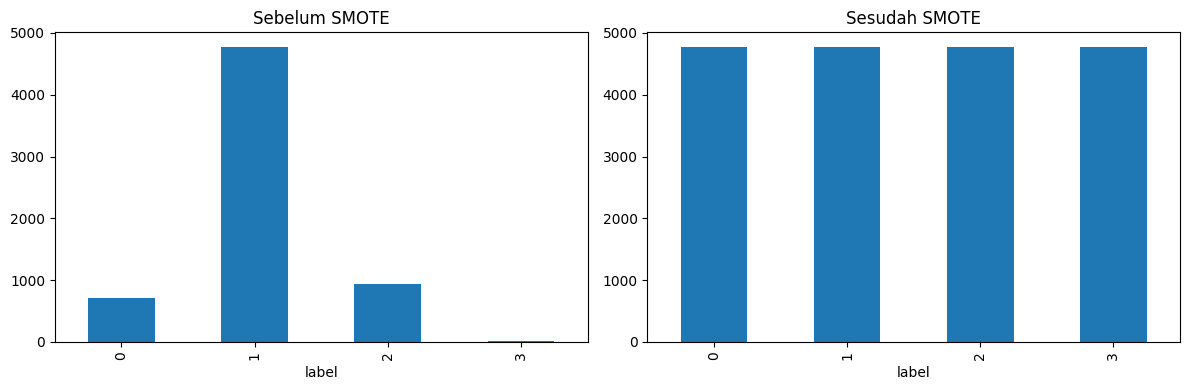

In [40]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

y_klf_train.value_counts().sort_index().plot(
    kind='bar', ax=ax[0])
ax[0].set_title('Sebelum SMOTE')

y_klf_train_smote.value_counts().sort_index().plot(
    kind='bar', ax=ax[1])
ax[1].set_title('Sesudah SMOTE')

plt.tight_layout()
plt.show()

# 13. Modelling

## 13.1. Model untuk Regresi

In [41]:
import lightgbm as lgb
import optuna
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

hasil_regresi = {}

for target in polutan:
    print(f"\n{'='*50}")
    print(f"Training regresi: {target.upper()}")

    def objective(trial):
        params = {
            'objective'        : 'regression',
            'metric'           : 'mae',
            'verbosity'        : -1,
            'boosting_type'    : 'gbdt',
            'n_estimators'     : trial.suggest_int('n_estimators', 300, 1500),
            'learning_rate'    : trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
            'num_leaves'       : trial.suggest_int('num_leaves', 20, 200),
            'max_depth'        : trial.suggest_int('max_depth', 3, 15),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
            'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
            'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
            'min_split_gain'   : trial.suggest_float('min_split_gain', 0.0, 1.0),
            'max_bin'          : trial.suggest_int('max_bin', 100, 500),
            'random_state'     : 42,
        }
        model = lgb.LGBMRegressor(**params)
        model.fit(
            x_reg_train[regresi], y_reg_train[target],
            eval_set=[(x_reg_test[regresi], y_reg_test[target])],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
        )
        preds = model.predict(x_reg_test[regresi])
        return mean_absolute_error(y_reg_test[target], preds)

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=150, show_progress_bar=True)

    best_params = study.best_params
    best_params.update({'objective':'regression','metric':'mae',
                        'verbosity':-1,'random_state':42})

    model_reg = lgb.LGBMRegressor(**best_params)
    model_reg.fit(x_reg_train[regresi], y_reg_train[target])

    preds = model_reg.predict(x_reg_test[regresi])
    mae   = mean_absolute_error(y_reg_test[target], preds)
    rmse  = mean_squared_error(y_reg_test[target], preds) ** 0.5
    r2    = r2_score(y_reg_test[target], preds)

    hasil_regresi[target] = {'model': model_reg, 'MAE': mae, 'RMSE': rmse, 'R2': r2}
    joblib.dump(model_reg, f'model/lgbm_reg_{target}.pkl')
    print(f"  MAE={mae:.3f} | RMSE={rmse:.3f} | R²={r2:.3f}")
    print(f"  Model disimpan → model/lgbm_reg_{target}.pkl")

print("\nSemua model regresi selesai ditraining!")


Training regresi: PM10


  0%|          | 0/150 [00:00<?, ?it/s]

  MAE=4.189 | RMSE=6.093 | R²=0.854
  Model disimpan → model/lgbm_reg_pm10.pkl

Training regresi: PM25


  0%|          | 0/150 [00:00<?, ?it/s]

  MAE=5.874 | RMSE=9.255 | R²=0.839
  Model disimpan → model/lgbm_reg_pm25.pkl

Training regresi: SO2


...

  MAE=2.473 | RMSE=4.020 | R²=0.682
  Model disimpan → model/lgbm_reg_co.pkl

Training regresi: O3


  0%|          | 0/150 [00:00<?, ?it/s]

  MAE=3.250 | RMSE=5.311 | R²=0.958
  Model disimpan → model/lgbm_reg_o3.pkl

Training regresi: NO2


  0%|          | 0/150 [00:00<?, ?it/s]

  MAE=3.653 | RMSE=5.699 | R²=0.822
  Model disimpan → model/lgbm_reg_no2.pkl

Semua model regresi selesai ditraining!


## 13.2. Model untuk Klasifikasi

In [42]:
from sklearn.metrics import accuracy_score, f1_score
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from xgboost import XGBClassifier

print("Training klasifikasi dengan Ensemble (Stacking)...")

# ── Step 1: Optuna untuk LightGBM base ───────────────────────────
def objective_klf(trial):
    params = {
        'objective'        : 'multiclass',
        'num_class'        : len(urutan_kelas),
        'metric'           : 'multi_logloss',
        'verbosity'        : -1,
        'boosting_type'    : 'gbdt',
        'n_estimators'     : trial.suggest_int('n_estimators', 300, 1500),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 200),
        'max_depth'        : trial.suggest_int('max_depth', 3, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'min_split_gain'   : trial.suggest_float('min_split_gain', 0.0, 1.0),
        'max_bin'          : trial.suggest_int('max_bin', 100, 500),
        'random_state'     : 42,
    }
    model = lgb.LGBMClassifier(**params)
    model.fit(
        x_klf_train_smote[klasifikasi], y_klf_train_smote,
        eval_set=[(x_klf_test[klasifikasi], y_klf_test)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
    )
    preds = model.predict(x_klf_test[klasifikasi])
    return f1_score(y_klf_test, preds, average='macro')

study_klf = optuna.create_study(direction='maximize')
study_klf.optimize(objective_klf, n_trials=150, show_progress_bar=True)
print(f"Best F1 (LightGBM): {study_klf.best_value:.4f}")

# ── Step 2: Bangun Stacking Ensemble ─────────────────────────────
best_klf = study_klf.best_params
best_klf.update({
    'objective'  : 'multiclass',
    'num_class'  : len(urutan_kelas),
    'metric'     : 'multi_logloss',
    'verbosity'  : -1,
    'random_state': 42,
})

lgbm_base = lgb.LGBMClassifier(**best_klf)
rf_base   = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
xgb_base  = XGBClassifier(n_estimators=300, random_state=42,
                           eval_metric='mlogloss', verbosity=0)

model_klf = StackingClassifier(
    estimators=[
        ('lgbm', lgbm_base),
        ('rf',   rf_base),
        ('xgb',  xgb_base),
    ],
    final_estimator=lgb.LGBMClassifier(
        n_estimators=200, random_state=42, verbosity=-1
    ),
    cv=5,
    n_jobs=-1,
)

model_klf.fit(x_klf_train_smote[klasifikasi], y_klf_train_smote)

# ── Step 3: Evaluasi cepat ────────────────────────────────────────
preds_ens = model_klf.predict(x_klf_test[klasifikasi])
acc = accuracy_score(y_klf_test, preds_ens)
f1  = f1_score(y_klf_test, preds_ens, average='macro')
print(f"\nEnsemble Accuracy : {acc:.4f}")
print(f"Ensemble F1 Macro : {f1:.4f}")

joblib.dump(model_klf, 'model/lgbm_klasifikasi.pkl')
print("Ensemble model disimpan → model/lgbm_klasifikasi.pkl")

Training klasifikasi dengan Ensemble (Stacking)...


  0%|          | 0/150 [00:00<?, ?it/s]

Best F1 (LightGBM): 0.8751

Ensemble Accuracy : 0.9813
Ensemble F1 Macro : 0.8527
Ensemble model disimpan → model/lgbm_klasifikasi.pkl


Classification Report:
                    precision    recall  f1-score   support

              BAIK       0.94      0.95      0.94       175
            SEDANG       0.99      0.99      0.99      1193
       TIDAK SEHAT       0.98      0.97      0.98       234
SANGAT TIDAK SEHAT       0.40      0.67      0.50         3

          accuracy                           0.98      1605
         macro avg       0.83      0.89      0.85      1605
      weighted avg       0.98      0.98      0.98      1605



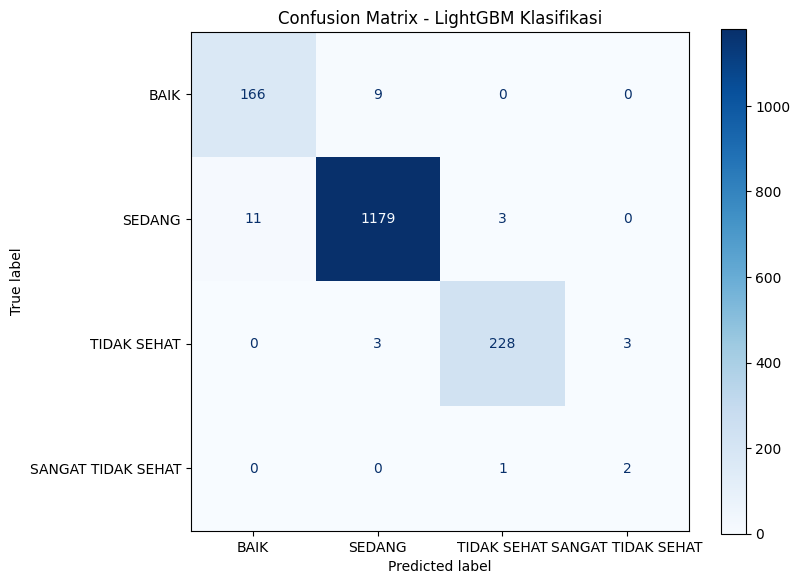


ROC-AUC (macro, OvR): 0.9684

Kelas hadir di test: ['BAIK', 'SEDANG', 'TIDAK SEHAT', 'SANGAT TIDAK SEHAT']
Kelas tidak muncul : ['BERBAHAYA']


In [43]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, ConfusionMatrixDisplay)
from sklearn.preprocessing import label_binarize

y_pred = model_klf.predict(x_klf_test)
y_prob = model_klf.predict_proba(x_klf_test)

# Ambil kelas yang benar-benar muncul di data test
labels_hadir = sorted(np.unique(np.concatenate([y_klf_test, y_pred])))
target_names_hadir = [urutan_kelas[i] for i in labels_hadir]

print("Classification Report:")
print(classification_report(
    y_klf_test, y_pred,
    labels=labels_hadir,
    target_names=target_names_hadir
))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_klf_test, y_pred,
    display_labels=target_names_hadir,
    cmap='Blues', ax=ax
)
plt.title('Confusion Matrix - LightGBM Klasifikasi')
plt.tight_layout()
plt.savefig('output/confusion_matrix.png', dpi=150)
plt.show()

# ROC-AUC — sesuaikan dengan jumlah kelas yang ada di test
y_bin = label_binarize(y_klf_test, classes=labels_hadir)
y_prob_hadir = y_prob[:, labels_hadir]  # ambil kolom prob sesuai kelas yang hadir

if len(labels_hadir) > 2:
    roc_auc = roc_auc_score(y_bin, y_prob_hadir, multi_class='ovr', average='macro')
    print(f"\nROC-AUC (macro, OvR): {roc_auc:.4f}")
else:
    roc_auc = roc_auc_score(y_bin, y_prob_hadir[:, 1])
    print(f"\nROC-AUC: {roc_auc:.4f}")

print(f"\nKelas hadir di test: {target_names_hadir}")
print(f"Kelas tidak muncul : {[urutan_kelas[i] for i in range(len(urutan_kelas)) if i not in labels_hadir]}")

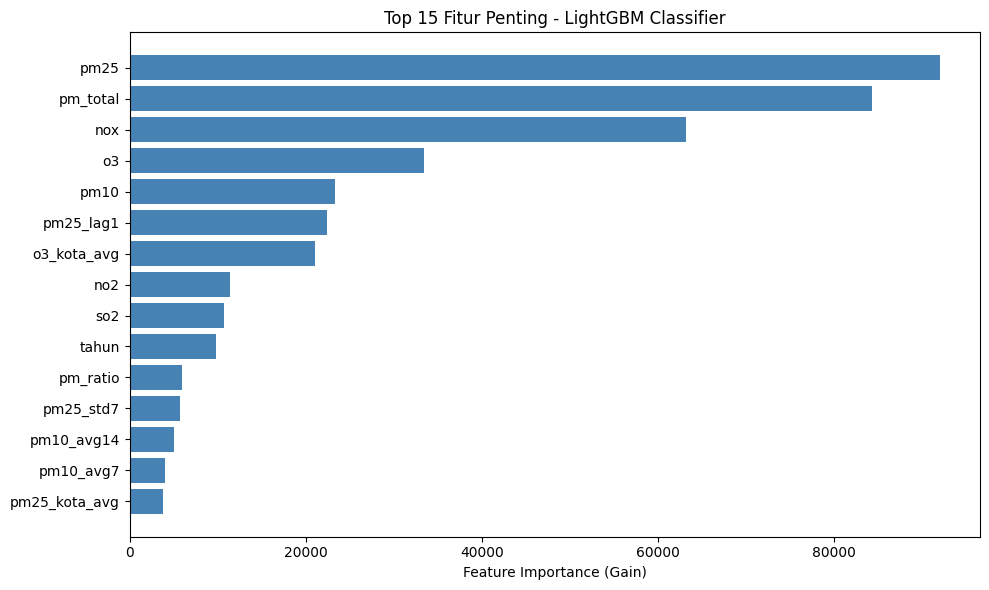


Top 15 Fitur:
        fitur   importance
         pm25 91950.002761
     pm_total 84253.118761
          nox 63215.486301
           o3 33432.011396
         pm10 23293.900949
    pm25_lag1 22458.872409
  o3_kota_avg 20998.378085
          no2 11423.138932
          so2 10761.686300
        tahun  9786.526478
     pm_ratio  5996.024837
    pm25_std7  5747.149185
   pm10_avg14  5079.759561
    pm10_avg7  4033.940106
pm25_kota_avg  3815.329423

Feature importance disimpan → model/feature_importance.pkl


In [46]:
# Feature Importance LightGBM (pengganti SHAP)
import matplotlib.pyplot as plt

# Ambil model LightGBM dari dalam stacking
lgbm_dalam_stacking = model_klf.estimators_[0]

importance = lgbm_dalam_stacking.booster_.feature_importance(importance_type='gain')
fitur_imp  = pd.DataFrame({
    'fitur'     : klasifikasi,
    'importance': importance
}).sort_values('importance', ascending=False)

# Plot top 15
top15 = fitur_imp.head(15)
plt.figure(figsize=(10, 6))
plt.barh(top15['fitur'][::-1], top15['importance'][::-1], color='steelblue')
plt.xlabel('Feature Importance (Gain)')
plt.title('Top 15 Fitur Penting - LightGBM Classifier')
plt.tight_layout()
plt.savefig('output/feature_importance.png', dpi=150)
plt.show()

print("\nTop 15 Fitur:")
print(top15.to_string(index=False))

# Simpan feature importance (pengganti shap_explainer.pkl)
joblib.dump(fitur_imp, 'model/feature_importance.pkl')
print("\nFeature importance disimpan → model/feature_importance.pkl")

In [47]:
joblib.dump(le_stasiun,  'model/le_stasiun.pkl')
joblib.dump(label2idx,   'model/label2idx.pkl')
joblib.dump(idx2label,   'model/idx2label.pkl')
joblib.dump(regresi,     'model/fitur_regresi.pkl')
joblib.dump(klasifikasi, 'model/fitur_klasifikasi.pkl')

print("Artefak tersimpan:")
print(f"  le_stasiun   : {le_stasiun.classes_.tolist()}")
print(f"  label2idx    : {label2idx}")
print(f"  fitur regresi: {len(regresi)} fitur")
print(f"  fitur klasif : {len(klasifikasi)} fitur")

Artefak tersimpan:
  le_stasiun   : ['DKI1 (Bunderan HI)', 'DKI2 (Kelapa Gading)', 'DKI3 (Jagakarsa)', 'DKI4 (Lubang Buaya)', 'DKI5 (Kebon Jeruk)']
  label2idx    : {'BAIK': 0, 'SEDANG': 1, 'TIDAK SEHAT': 2, 'SANGAT TIDAK SEHAT': 3, 'BERBAHAYA': 4}
  fitur regresi: 59 fitur
  fitur klasif : 42 fitur


In [48]:
# Simpan data final untuk FastAPI
import os
os.makedirs('data/bersih', exist_ok=True)

df.to_csv('data/bersih/ispu_gabungan_2019_2025.csv', index=False)
print(f"Data disimpan: {df.shape}")
print(f"Kolom tanggal sample: {df['tanggal'].head(3).tolist()}")
print(f"Stasiun unik: {df['lokasi_spku'].unique().tolist()}")

Data disimpan: (8025, 79)
Kolom tanggal sample: [Timestamp('2020-10-06 00:00:00'), Timestamp('2021-01-01 00:00:00'), Timestamp('2021-01-02 00:00:00')]
Stasiun unik: ['DKI1 (Bunderan HI)', 'DKI2 (Kelapa Gading)', 'DKI3 (Jagakarsa)', 'DKI4 (Lubang Buaya)', 'DKI5 (Kebon Jeruk)']
